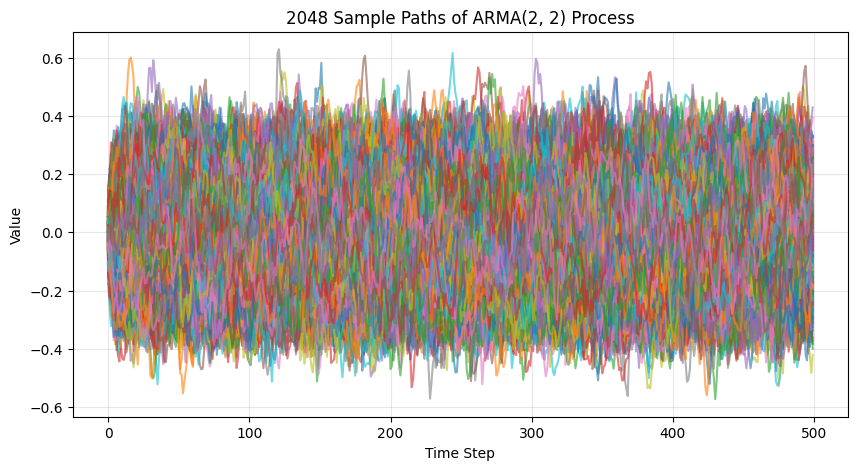

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
import os
seed = 44
np.random.seed(seed)

ar = np.array([1, -0.9, 0.01])
ma = np.array([1, 0.1, 0.1])

# 2. Generate Multiple Pathsc
# nsample=(Length, Number of Paths)
T =500  # Time steps
N =2048  # Number of independent paths
process = ArmaProcess(ar, ma)

# This returns a shape (100, 10) array
paths_matrix = process.generate_sample(nsample=(T, N), scale=0.05)

# 3. Visualization
plt.figure(figsize=(10, 5))
plt.plot(paths_matrix, alpha=0.6) # Plots all columns automatically
plt.title(f"{N} Sample Paths of ARMA(2, 2) Process")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.show()
# 
# 4. Save data
# directory_path = f'/home/yinbinha/adapted_diffusion_model/data/ARMA/seed{seed}/'

# os.makedirs(directory_path, exist_ok=True)
# np.save(f'{directory_path}AR_2_0.9_-0.01_MA_2_0.1_0.1_T{T}_N{N}_seed{seed}.npy', paths_matrix.T)

In [2]:
# --- 1. Theoretical Ground Truth ---
# Remember statsmodels sign convention
ar_params = ar
ma_params = ma
process = ArmaProcess(ar_params, ma_params)

# Get theoretical curves (up to lag 20)
theo_acf = process.acf(lags=40)
theo_pacf = process.pacf(lags=20)

In [3]:
from statsmodels.tsa.stattools import acf, pacf

# --- 2. Empirical (Synthetic) ---
# Compute ACF/PACF for every single path
train_acfs = []
train_pacfs = []

for row in paths_matrix.T:
    train_acfs.append(acf(row, nlags=39, fft=True))
    train_pacfs.append(pacf(row, nlags=19))
    
train_acfs = np.array(train_acfs)
train_pacfs = np.array(train_pacfs)

# Mean and Confidence Interval (1 std dev)
train_mean_acf = train_acfs.mean(axis=0)
train_std_acf = train_acfs.std(axis=0)

train_mean_pacf = train_pacfs.mean(axis=0)
train_std_pacf = train_pacfs.std(axis=0)

In [4]:
import glob
import os

# Folder path
folder = "/home/yinbinha/adapted_diffusion_model/samples/dfm_AR_2_0.9_-0.01_MA_2_0.1_0.1_T500_N2048_seed44_ts1769640523_seed44"

# Get all batch files sorted by batch number
files = sorted(glob.glob(os.path.join(folder, "sample_batch*.npy")))

# Load and combine
arrays = []
for f in files:
    arr = np.load(f)
    if arr.shape[1] != 500:
        raise ValueError(f"File {f} has unexpected shape {arr.shape}")
    arrays.append(arr)
    
dit = np.concatenate(arrays, axis=0)

In [5]:
# --- 2. Empirical (Generated) ---
# Compute ACF/PACF for every single path
gen_acfs = []
gen_pacfs = []

for row in dit:
    gen_acfs.append(acf(row, nlags=39, fft=True))
    gen_pacfs.append(pacf(row, nlags=19))
    
gen_acfs = np.array(gen_acfs)
gen_pacfs = np.array(gen_pacfs)

# Mean and Confidence Interval (1 std dev)
gen_mean_acf = gen_acfs.mean(axis=0)
gen_std_acf = gen_acfs.std(axis=0)

gen_mean_pacf = gen_pacfs.mean(axis=0)
gen_std_pacf = gen_pacfs.std(axis=0)

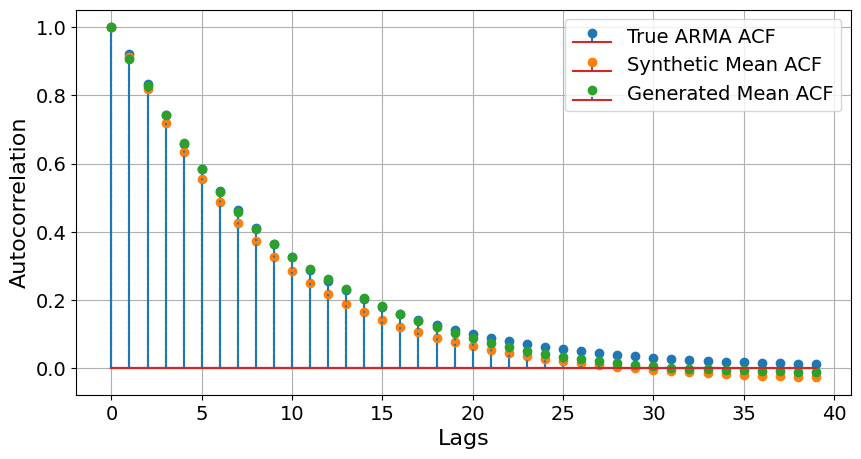

In [9]:
import matplotlib.pyplot as plt

lags_range = np.arange(len(theo_acf))

plt.figure(figsize=(10, 5))

# True ACF (solid line)
# plt.plot(lags_range, theo_acf, label="True ARMA ACF", linewidth=2)
markerline, stemlines, baseline = plt.stem(lags_range, theo_acf, label="True ARMA ACF", linefmt="-")


# Mean synthetic ACF (dashed line)
# plt.plot(lags_range, train_mean_acf, label="Sample Mean ACF", linestyle='--', linewidth=2)
markerline, stemlines, baseline = plt.stem(lags_range, train_mean_acf, label="Synthetic Mean ACF", linefmt="-.")

# plt.plot(lags_range, mean_acf, label="Generated Mean ACF", linestyle='-.', linewidth=2)
markerline, stemlines, baseline = plt.stem(lags_range, gen_mean_acf, label="Generated Mean ACF", linefmt=":")



# # Optional: 1 std confidence band around generated ACF
# plt.fill_between(
#     lags_range,
#     gen_mean_acf - gen_std_acf,
#     gen_mean_acf + gen_std_acf,
#     alpha=0.2,
#     label="Generated ACF ± 1 std"
# )


plt.xlabel("Lags", fontsize=16)
plt.ylabel("Autocorrelation", fontsize=16)
# plt.title("True ACF vs Sample ACF vs Generated ACF", fontsize=14)
# plt.title("Synthetic ACF vs Generated ACF (H = 40)", fontsize=16)
plt.legend(fontsize=14)
plt.grid(True)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# plt.savefig('/home/yinbinha/adapted_diffusion_model/figs/H500_n2048_large.png', dpi=300, bbox_inches='tight')

plt.show()



In [7]:
np.linalg.norm(gen_mean_acf - theo_acf, 1) / np.linalg.norm(theo_acf, 1)

0.05556743393749199

In [8]:
np.linalg.norm(train_mean_acf - theo_acf, 1) / np.linalg.norm(theo_acf, 1)

0.1452384234924128

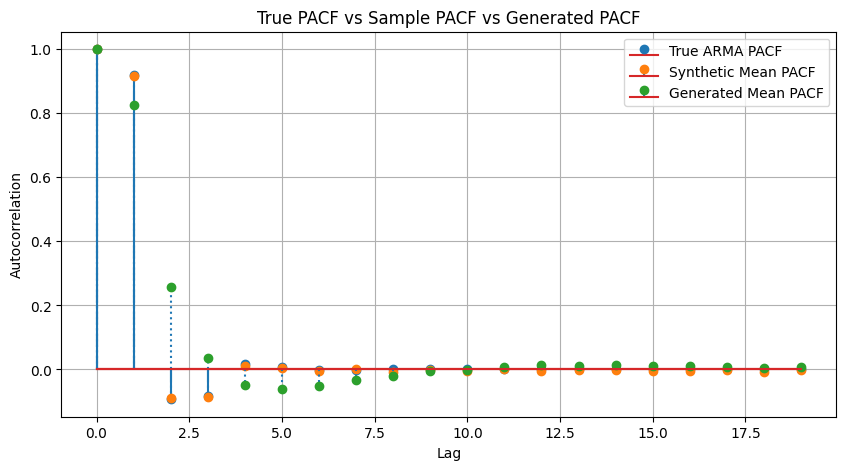

In [36]:
lags_range = np.arange(len(theo_pacf))

plt.figure(figsize=(10, 5))

# True ACF (solid line)
# plt.plot(lags_range, theo_acf, label="True ARMA ACF", linewidth=2)
markerline, stemlines, baseline = plt.stem(lags_range, theo_pacf, label="True ARMA PACF", linefmt="-")


# Mean generated ACF (dashed line)
# plt.plot(lags_range, train_mean_acf, label="Sample Mean ACF", linestyle='--', linewidth=2)
markerline, stemlines, baseline = plt.stem(lags_range, train_mean_pacf, label="Synthetic Mean PACF", linefmt="-.")

# plt.plot(lags_range, mean_acf, label="Generated Mean ACF", linestyle='-.', linewidth=2)
markerline, stemlines, baseline = plt.stem(lags_range, gen_mean_pacf, label="Generated Mean PACF", linefmt=":")



# # Optional: 1 std confidence band around generated ACF
# plt.fill_between(
#     lags_range,
#     gen_mean_pacf - gen_std_pacf,
#     gen_mean_pacf + gen_std_pacf,
#     alpha=0.2,
#     label="Generated PACF ± 1 std"
# )

plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("True PACF vs Sample PACF vs Generated PACF")
plt.legend()
plt.grid(True)
plt.show()

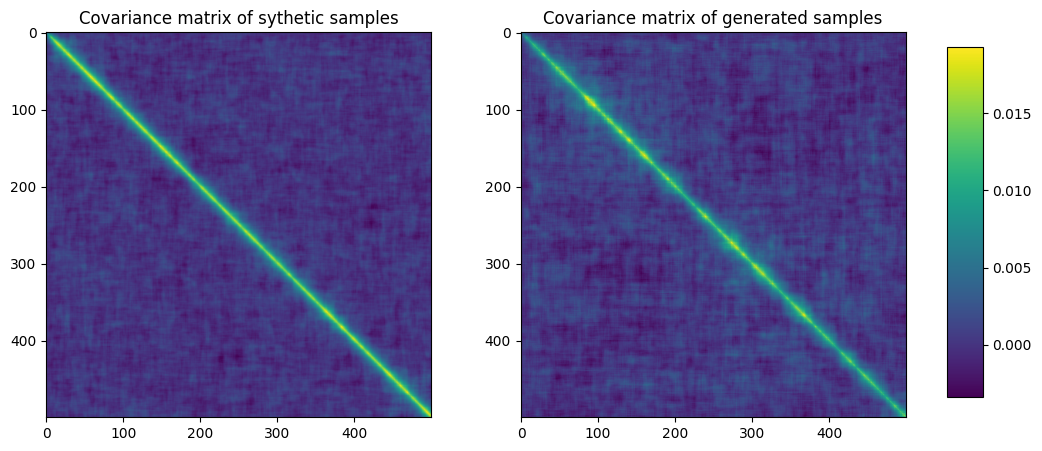

In [297]:
# 1. Compute Empirical Covariance from your samples
# Rowvar=False assumes rows are observations, columns are variables
emp_cov_matrix = np.cov(paths_matrix.T, rowvar=False)
gen_cov_matrix = np.cov(dit, rowvar=False)


# 2. Setup the Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Determine min/max for colorbar scaling so both plots use the same scale
vmin = emp_cov_matrix.min()
vmax = emp_cov_matrix.max()

# 3. Plot Empirical Covariance (Left)
im1 = axes[0].imshow(emp_cov_matrix, cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title('Covariance matrix of sythetic samples')

# 4. Plot True Covariance (Right)
im2 = axes[1].imshow(gen_cov_matrix, cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title('Covariance matrix of generated samples')

# 5. Add a shared Colorbar
# adjustment to place colorbar nicely on the right
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7]) # [left, bottom, width, height]
fig.colorbar(im2, cax=cbar_ax)

plt.show()

In [244]:
np.linalg.norm(gen_cov_matrix - emp_cov_matrix) / np.linalg.norm(emp_cov_matrix)

0.5079396060164671